#Task 1: Data Cleaning and Formatting

- The dataset was cleaned and formatted to ensure consistency and accuracy for further analysis.

- Key preprocessing steps included handling missing values, converting data types, and standardizing categorical variables.

In [ ]:
# Import file upload utility (Google Colab specific)
from google.colab import files
uploaded = files.upload()

Saving jp_morgan.csv to jp_morgan (1).csv


In [ ]:
import pandas as pd
# Read dataset into DataFrame
df = pd.read_csv("jp_morgan.csv")
# Preview first 5 rows to understand structure
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13


In [ ]:
# Get dataset structure (columns, data types, nulls)
df.info()
# Summary statistics (mean, std, min, max, etc.)
df.describe()
# Count missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


,0
TransactionID,0
CustomerID,0
AccountID,0
AccountType,0
TransactionType,0
Product,0
Firm,0
Region,0
Manager,0
TransactionDate,0


In [ ]:
# Convert 'TransactionDate' to datetime format
# errors='coerce' converts invalid dates to NaT (missing)
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')

In [ ]:
# Drop rows where date conversion failed
df = df.dropna(subset=['TransactionDate'])

In [ ]:
# Convert 'TransactionAmount' to numeric
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'], errors='coerce')
# Convert 'AccountBalance' to numeric
df['AccountBalance'] = pd.to_numeric(df['AccountBalance'], errors='coerce')

In [ ]:
# Standardize text: lowercase + remove extra spaces
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()
df['AccountType'] = df['AccountType'].str.lower().str.strip()

In [ ]:
# Sort by Customer + Date
df = df.sort_values(by=['CustomerID', 'TransactionDate'])

# Calculate gap between transactions per customer
df['gap_days'] = df.groupby('CustomerID')['TransactionDate'].diff().dt.days

# Fill missing values (first transaction per customer will be NaN)
df['gap_days'] = df['gap_days'].fillna(df['gap_days'].median())

In [ ]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
AccountID,0
AccountType,0
TransactionType,0
Product,0
Firm,0
Region,0
Manager,0
TransactionDate,0


##Key Observations
- The dataset initially contained inconsistencies in date formatting, which resulted in missing values during conversion.
- By specifying the correct format (%d-%m-%Y), most date entries were successfully recovered.
- Missing values were handled selectively to avoid unnecessary data loss, ensuring maximum data retention.
- Feature engineering steps such as calculating transaction gaps introduced expected null values, which were handled appropriately using median imputation.
- Overall, the dataset was transformed into a clean and analysis-ready format while preserving data integrity.


---



#Task 2:  Descriptive Transactional Analysis

- This task focuses on analyzing transaction patterns across time to understand customer financial behavior.

- Monthly and yearly trends were evaluated, along with comparisons between credit and debit transactions, to identify performance patterns and account activity levels.

In [ ]:
# Extract Month and Year from TransactionDate for trend analysis
df['Month'] = df['TransactionDate'].dt.to_period('M')
df['Year'] = df['TransactionDate'].dt.year

In [ ]:
# Group data by Month and Transaction Type
# Calculate total transaction amount
monthly_summary = df.groupby(['Month', 'TransactionType'])['TransactionAmount'].sum().unstack()

monthly_summary

TransactionType,deposit,payment,transfer,withdrawal
Month,,,,
2023-01,586442.427030,892403.329063,5.115039e+05,815781.122358
2023-02,788091.358440,896472.509573,6.413965e+05,439855.688290
2023-03,568405.450700,621706.357696,4.394253e+05,845856.681975
2023-04,593836.810010,712652.450490,5.190421e+05,883698.507661
2023-05,729309.615730,633500.534446,8.187420e+05,415485.163630
2023-06,803711.145215,418534.073490,6.538772e+05,334492.261481
2023-07,793971.625099,336955.911862,5.874381e+05,728699.213130
2023-08,880993.233920,290117.922898,4.273862e+05,553210.376340
2023-09,699282.350630,549523.220810,2.940494e+05,572834.757190


In [ ]:
# Replace missing values with 0 for clean analysis
monthly_summary = monthly_summary.fillna(0)
# Sort months chronologically
monthly_summary = monthly_summary.sort_index()
# Convert Period index to string for better readability in plots
monthly_summary.index = monthly_summary.index.astype(str)

# Net = Inflow (deposit) - Outflow (withdrawal + payment
monthly_summary['Net'] = monthly_summary.get('deposit', 0) - (
    monthly_summary.get('withdrawal', 0) +
    monthly_summary.get('payment', 0)
)

monthly_summary

TransactionType,deposit,payment,transfer,withdrawal,Net
Month,,,,,
2023-01,586442.427030,892403.329063,5.115039e+05,815781.122358,-1.121742e+06
2023-02,788091.358440,896472.509573,6.413965e+05,439855.688290,-5.482368e+05
2023-03,568405.450700,621706.357696,4.394253e+05,845856.681975,-8.991576e+05
2023-04,593836.810010,712652.450490,5.190421e+05,883698.507661,-1.002514e+06
2023-05,729309.615730,633500.534446,8.187420e+05,415485.163630,-3.196761e+05
2023-06,803711.145215,418534.073490,6.538772e+05,334492.261481,5.068481e+04
2023-07,793971.625099,336955.911862,5.874381e+05,728699.213130,-2.716835e+05
2023-08,880993.233920,290117.922898,4.273862e+05,553210.376340,3.766493e+04
2023-09,699282.350630,549523.220810,2.940494e+05,572834.757190,-4.230756e+05


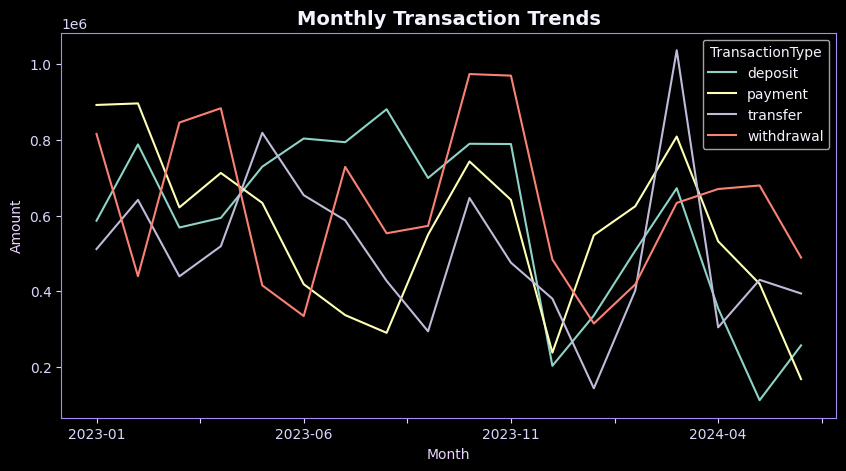

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#000000',
    'axes.facecolor': '#000000',
    'axes.edgecolor': '#a78bfa',
    'axes.labelcolor': '#e9d5ff',
    'xtick.color': '#ddd6fe',
    'ytick.color': '#ddd6fe',
    'text.color': '#f5f3ff',
    'grid.color': '#4c1d95',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14
})
# Plot transaction trends over time
monthly_summary[['deposit','payment','transfer','withdrawal']].plot(figsize=(10,5))

plt.title("Monthly Transaction Trends")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.show()

##Trend Interpretation

- Transaction volumes show significant fluctuations across months, indicating dynamic customer activity.
- Withdrawals and payments often dominate over deposits in several periods, suggesting higher spending behavior.
- Transfer transactions exhibit occasional spikes, which may correspond to large fund movements or business-related activities.

In [ ]:
yearly_summary = df.groupby(['Year', 'TransactionType'])['TransactionAmount'].sum().unstack()
yearly_summary

TransactionType,deposit,payment,transfer,withdrawal
Year,,,,
2023,8.225787e+06,6.974170e+06,6.395137e+06,8.017619e+06
2024,2.238946e+06,3.100943e+06,2.711474e+06,3.205223e+06


In [ ]:
# Convert transactions into inflow (+) and outflow (-)
df['SignedAmount'] = df.apply(
    lambda x: x['TransactionAmount'] if x['TransactionType'] == 'deposit'
    else -x['TransactionAmount'],
    axis=1
)

# Calculate total inflow/outflow per account
net_inflow = df.groupby('AccountID')['SignedAmount'].sum().sort_values(ascending=False)

net_inflow.head()

,SignedAmount
AccountID,
ACC54589,225122.495180
ACC67713,189071.785288
ACC74631,150954.104630
ACC87602,150860.567520
ACC22036,145164.795582


In [ ]:
# Top and bottom performing accounts
top_accounts = net_inflow.head(5)
bottom_accounts = net_inflow.tail(5)

top_accounts
bottom_accounts

,SignedAmount
AccountID,
ACC81631,-342531.377190
ACC11285,-373189.528410
ACC51593,-414370.119240
ACC55331,-448188.410346
ACC18140,-458219.210460


In [ ]:
# Identify accounts with large inactivity gaps
df = df.sort_values(['AccountID', 'TransactionDate'])

df['gap_days'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

# Define inactivity threshold (custom criteria)
# Accounts with gaps > 60 days are considered dormant
dormant_accounts = df[df['gap_days'] > 60]['AccountID'].unique()

print(f"Number of dormant accounts: {dormant_accounts}")


Number of dormant accounts: ['ACC10996' 'ACC11062' 'ACC11188' 'ACC11285' 'ACC12182' 'ACC12334'
 'ACC13357' 'ACC15228' 'ACC15359' 'ACC15671' 'ACC15925' 'ACC16664'
 'ACC17688' 'ACC18140' 'ACC19156' 'ACC19178' 'ACC20297' 'ACC21264'
 'ACC21429' 'ACC21719' 'ACC21878' 'ACC22036' 'ACC22255' 'ACC22799'
 'ACC23736' 'ACC23985' 'ACC24070' 'ACC24508' 'ACC24880' 'ACC24981'
 'ACC25132' 'ACC25811' 'ACC26026' 'ACC26956' 'ACC26973' 'ACC28154'
 'ACC28295' 'ACC28305' 'ACC28612' 'ACC29007' 'ACC29231' 'ACC29356'
 'ACC29396' 'ACC29477' 'ACC30787' 'ACC30852' 'ACC31539' 'ACC31902'
 'ACC32212' 'ACC32627' 'ACC32890' 'ACC33287' 'ACC34119' 'ACC34431'
 'ACC34568' 'ACC34821' 'ACC35163' 'ACC35419' 'ACC36079' 'ACC37688'
 'ACC38559' 'ACC39161' 'ACC39500' 'ACC39529' 'ACC39544' 'ACC40952'
 'ACC42467' 'ACC42710' 'ACC42903' 'ACC43309' 'ACC43771' 'ACC45101'
 'ACC45907' 'ACC45951' 'ACC45968' 'ACC46655' 'ACC47099' 'ACC48303'
 'ACC48501' 'ACC49140' 'ACC49395' 'ACC49422' 'ACC50439' 'ACC50817'
 'ACC51009' 'ACC51200' 'ACC51593' 

##Key Observations
- Transaction volumes fluctuate significantly across months, indicating dynamic customer activity.
- Withdrawals and payments often exceed deposits, reflecting spending-heavy behavior.
- A small number of accounts drive most of the net inflow, highlighting high-value customers.
- 164 accounts were identified as dormant, indicating low engagement.

## Insights

- Customers exhibit consumption-driven behavior with higher outflows than inflows.
- Revenue is concentrated among a few high-value accounts, creating dependency risk.
- Dormant accounts present re-engagement opportunities.
- Inactivity beyond 60 days signals potential churn risk.
- Withdrawal spikes may indicate seasonal spending or financial stress.

---



#Task 3: Customer Profile Building

- This task focuses on segmenting customers based on their transaction behavior and financial characteristics.

- Customers were classified using transaction frequency, average balance, and transaction volume to identify behavioral patterns and key financial segments.

Customers were categorized based on transaction frequency:

- High Activity: More than 50 transactions  
- Medium Activity: Between 20 and 50 transactions  
- Low Activity: Less than 20 transactions  

This classification helps in understanding customer engagement and usage intensity.

In [ ]:
# Count number of transactions for each account
txn_count = df.groupby('AccountID').size()
txn_count.head()

,0
AccountID,
ACC10117,1
ACC10996,4
ACC11062,4
ACC11188,3
ACC11285,6


In [ ]:
# Categorize accounts based on transaction frequency
def activity_level(x):
    if x > 50:
        return "High"
    elif x > 20:
        return "Medium"
    else:
        return "Low"

# Apply classification
activity = txn_count.apply(activity_level)

In [ ]:
# Calculate average balance and total transaction volume
avg_balance = df.groupby('AccountID')['AccountBalance'].mean()
txn_volume = df.groupby('AccountID')['TransactionAmount'].sum()

In [ ]:
# Combine all metrics into a single profile dataset
profile = pd.DataFrame({
    'TransactionCount': txn_count,
    'ActivityLevel': activity,
    'AvgBalance': avg_balance,
    'TransactionVolume': txn_volume
})

profile.head()

,TransactionCount,ActivityLevel,AvgBalance,TransactionVolume
AccountID,,,,
ACC10117,1,Low,90780.256640,56317.920060
ACC10996,4,Low,64046.568590,223757.534516
ACC11062,4,Low,62784.100737,265928.583340
ACC11188,3,Low,80558.926400,116557.954500
ACC11285,6,Low,95745.546255,373189.528410


In [ ]:
# Identify accounts with high transaction volume (top 25%)
high_inflow = profile[profile['TransactionVolume'] > profile['TransactionVolume'].quantile(0.75)]

In [ ]:
# Accounts with frequent transactions but low balance
low_balance_high_freq = profile[
    (profile['TransactionCount'] > profile['TransactionCount'].quantile(0.75)) &
    (profile['AvgBalance'] < profile['AvgBalance'].median())
]

In [ ]:
# Bottom 25% accounts by balance
low_balance_accounts = profile[
    profile['AvgBalance'] < profile['AvgBalance'].quantile(0.25)
]

In [ ]:
# Accounts with high average risk score
high_risk_profiles = df.groupby('AccountID')['RiskScore'].mean()
# Define threshold for high risk
high_risk_profiles = high_risk_profiles[high_risk_profiles > 0.7]

In [ ]:
high_inflow.head()
low_balance_high_freq.head()
low_balance_accounts.head()

,TransactionCount,ActivityLevel,AvgBalance,TransactionVolume
AccountID,,,,
ACC11062,4,Low,62784.100737,265928.583340
ACC15228,5,Low,62944.415270,230462.928100
ACC15671,6,Low,51776.654462,271421.883325
ACC22255,2,Low,48149.863135,166457.873850
ACC22799,3,Low,62709.252073,161040.650870


In [ ]:
#Segment Size Analysis
print("High inflow accounts:", len(high_inflow))
print("High freq low balance:", len(low_balance_high_freq))
print("Low balance accounts:", len(low_balance_accounts))

High inflow accounts: 49
High freq low balance: 22
Low balance accounts: 49


In [ ]:
high_risk_profiles = df.groupby('AccountID')['RiskScore'].mean()
high_risk_profiles = high_risk_profiles[high_risk_profiles > 0.7]

In [ ]:
profile.describe()

,TransactionCount,AvgBalance,TransactionVolume
count,194.000000,194.000000,194.000000
mean,4.123711,74761.057912,210666.492958
std,2.032165,18407.610264,116623.713109
min,1.000000,32962.941265,15159.688345
25%,3.000000,63122.243929,117854.869170
50%,4.000000,73249.914380,191634.845090
75%,5.000000,86623.934565,288431.144298
max,10.000000,166805.957700,539494.876440


In [ ]:
len(high_inflow)
len(high_inflow) / len(profile) * 100

25.257731958762886

##Customer Segments Identified

- High Inflow Accounts (49 | ~25%): Customers with transaction volume above the 75th percentile.
- High Activity, Low Balance (22): Frequently transacting customers with below-median balances.
- Low Balance Accounts (49): Customers in the bottom 25% of average balance.
- High Risk Profiles: Customers with average risk scores above 0.7.

##Key Observation
- Majority of customers fall under low activity, indicating limited engagement.
- High transaction volume is concentrated among ~25% of accounts.
- 22 customers exhibit high activity but low balances, indicating frequent usage with limited liquidity.
- A significant portion of customers maintain low balances, highlighting potential financial constraints.

###The presence of high activity but low balance customers suggests a segment of financially active yet liquidity-constrained users, making them potential targets for credit-based products and risk monitoring.

---



#Task 4: Financial Risk Identification
- This task focuses on identifying potentially risky accounts by analyzing transaction behavior and financial patterns.
- Various techniques such as withdrawal analysis, balance volatility, and anomaly detection were used to highlight irregular or suspicious financial activity.

In [ ]:
# Focus on debit transactions (outflows)
debits = df[df['TransactionType'] == 'debit']

In [ ]:
# Define threshold using 85th percentile (custom criteria)
threshold = debits['TransactionAmount'].quantile(0.85)
# Filter large withdrawals
large_withdrawals = debits[debits['TransactionAmount'] > threshold]

large_withdrawals.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,gap_days,Month,Year,SignedAmount


In [ ]:
# Count large withdrawals per account
freq_large_withdrawals = large_withdrawals.groupby('AccountID').size()
# Accounts with repeated large withdrawals (>1)
risky_withdrawal_accounts = freq_large_withdrawals[freq_large_withdrawals > 1]

risky_withdrawal_accounts

,0
AccountID,


In [ ]:
# Measure fluctuation in account balance using standard deviation
volatility = df.groupby('AccountID')['AccountBalance'].std()

volatility.head()

,AccountBalance
AccountID,
ACC10117,NaN
ACC10996,30390.798000
ACC11062,37598.383500
ACC11188,33781.833882
ACC11285,42139.172552


In [ ]:
# Top 25% most volatile accounts
high_volatility = volatility[volatility > volatility.quantile(0.75)]

high_volatility

,AccountBalance
AccountID,
ACC11285,42139.172552
ACC12182,41810.524025
ACC15925,38920.935537
ACC18140,39361.136146
ACC21719,43528.195697
ACC22036,40023.864093
ACC23736,49370.155344
ACC28295,48781.063965
ACC28612,59940.470436


In [ ]:
from scipy.stats import zscore

# Calculate Z-score for transaction amounts
df['z_score'] = zscore(df['TransactionAmount'])
# Flag extreme transactions (|z| > 3)
anomalies = df[df['z_score'].abs() > 3]

anomalies.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,gap_days,Month,Year,SignedAmount,z_score
53,178,CUST1189,ACC50439,savings,deposit,Savings Account,Firm D,East,Manager 1,2024-06-16,-60979.07348,57916.06101,0.160988,655,17,103.0,2024-06,2024,-60979.07348,-3.856562
397,51,CUST1497,ACC88074,current,transfer,Mutual Fund,Firm B,East,Manager 3,2024-03-05,-45352.95439,96125.56424,-0.203847,668,36,64.0,2024-03,2024,45352.95439,-3.318814
727,163,CUST1747,ACC92104,savings,deposit,Savings Account,Firm A,West,Manager 1,2023-08-06,147447.29510,101759.29850,0.099626,421,86,NaN,2023-08,2023,147447.29510,3.316099
242,86,CUST7855,ACC95164,savings,payment,Home Loan,Firm C,North,Manager 3,2023-10-26,143067.18460,73627.79044,0.752617,582,226,164.0,2023-10,2023,-143067.18460,3.165364


In [ ]:
# Combine accounts with multiple risk signals
suspicious_accounts = set(risky_withdrawal_accounts.index) | set(high_volatility.index)

suspicious_accounts

{'ACC11285',
 'ACC12182',
 'ACC15925',
 'ACC18140',
 'ACC21719',
 'ACC22036',
 'ACC23736',
 'ACC28295',
 'ACC28612',
 'ACC29007',
 'ACC30852',
 'ACC31902',
 'ACC33287',
 'ACC39161',
 'ACC39529',
 'ACC40952',
 'ACC42467',
 'ACC45521',
 'ACC45907',
 'ACC48303',
 'ACC49774',
 'ACC50817',
 'ACC51971',
 'ACC53865',
 'ACC54589',
 'ACC57516',
 'ACC57700',
 'ACC57872',
 'ACC58667',
 'ACC61827',
 'ACC61926',
 'ACC62446',
 'ACC64022',
 'ACC66086',
 'ACC66190',
 'ACC69323',
 'ACC71388',
 'ACC74656',
 'ACC76699',
 'ACC77638',
 'ACC78589',
 'ACC87602',
 'ACC88286',
 'ACC90887',
 'ACC95774',
 'ACC96868'}

In [ ]:
# Convert to list for analysis
suspicious_accounts = list(suspicious_accounts)

print(len(suspicious_accounts))
print((suspicious_accounts))

46
['ACC21719', 'ACC45907', 'ACC31902', 'ACC90887', 'ACC57516', 'ACC61827', 'ACC42467', 'ACC87602', 'ACC29007', 'ACC58667', 'ACC11285', 'ACC96868', 'ACC61926', 'ACC39529', 'ACC69323', 'ACC76699', 'ACC51971', 'ACC66086', 'ACC33287', 'ACC64022', 'ACC62446', 'ACC30852', 'ACC57872', 'ACC88286', 'ACC39161', 'ACC78589', 'ACC28295', 'ACC15925', 'ACC50817', 'ACC28612', 'ACC66190', 'ACC71388', 'ACC95774', 'ACC18140', 'ACC74656', 'ACC48303', 'ACC23736', 'ACC49774', 'ACC12182', 'ACC54589', 'ACC22036', 'ACC77638', 'ACC45521', 'ACC40952', 'ACC53865', 'ACC57700']


In [ ]:
len(suspicious_accounts)
len(suspicious_accounts) / df['AccountID'].nunique() * 100

23.711340206185564

Risk identification was based on a multi-factor approach:

- Transaction magnitude → Large withdrawals
- Behavioral instability → Balance volatility
- Statistical deviation → Z-score anomalies
- Combined indicators → Suspicious account identification

## Key Observations
- 46 accounts (~23.7%) flagged as suspicious using combined risk indicators.
- High volatility accounts show unstable balance behavior.
- Z-score analysis highlights extreme transaction deviations.
- Risk is concentrated in a small subset of accounts.

##Insights
- Combining volatility and anomaly detection improves risk identification accuracy.
- High volatility + unusual transactions indicate potential financial instability or fraud.
- Risk is clustered rather than widespread across customers.
- Multi-factor analysis is more effective than single-metric thresholds.

##Recommendations
- Implement multi-factor risk scoring for continuous monitoring.
- Set real-time alerts for high volatility and extreme transactions.
- Prioritize accounts flagged by multiple risk indicators.
- Enhance anomaly detection models for early fraud detection.
---



# Task 5: Visualisation & Insights

- This section focuses on visualizing key transaction patterns, customer activity levels, and financial risk indicators.
- The goal is to uncover trends, relationships, and anomalies that provide deeper insights into customer behavior and risk exposure.

In [ ]:
# Categorize accounts based on number of transactions
# Custom thresholds:
# >5 → High activity
# >2 → Medium activity
# ≤2 → Low activity
def activity_level(x):
    if x > 5:
        return 'High'
    elif x > 2:
        return 'Medium'
    else:
        return 'Low'

activity = txn_count.apply(activity_level)

### Customer Activity Distribution

**Insight**
- Majority of customers fall in low–medium activity segments.
- High activity users form a small but high-impact group.
- Transaction activity is concentrated among a limited set of users.

**Action**
- Retain high-activity users with targeted benefits.
- Activate low-activity users through engagement campaigns.

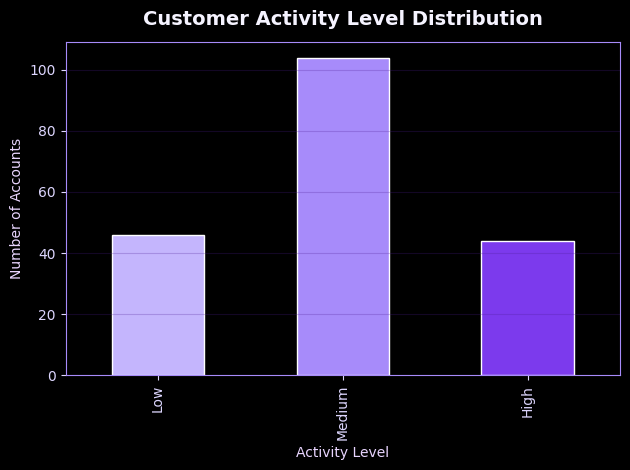

In [ ]:
# Visualize number of accounts in each activity segment
activity.value_counts().reindex(['Low','Medium','High']).plot(
    kind='bar',
    color=['#c4b5fd', '#a78bfa', '#7c3aed'],
    edgecolor='white'
)

plt.title("Customer Activity Level Distribution", pad=12)
plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")

# Add grid for better readability
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

###Transaction Volume Distribution
**Insight**
- Distribution is right-skewed with few high-volume customers.
- Majority contribute moderate transaction volumes.
- High-value customers drive a significant share of total volume.

**Action**
- Prioritize high-volume customers for personalized services.
- Monitor extreme volumes for anomaly detection.

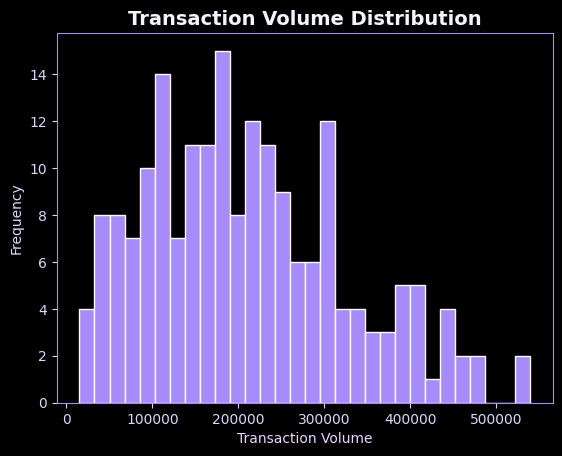

In [ ]:
# Understand spread of transaction volume across accounts
profile['TransactionVolume'].plot(
    kind='hist',
    bins=30,
    color='#a78bfa',
    edgecolor='white'
)
plt.title("Transaction Volume Distribution")
plt.xlabel("Transaction Volume")
plt.show()

###Balance vs Transaction Volume
**Insight**
- Weak relationship between transaction volume and account balance.
- Similar transaction levels show wide variation in balances.
- Volume alone is not a reliable indicator of financial strength.

**Action**
- Use multi-factor segmentation (balance + volume + risk).
- Avoid single-metric decision making.

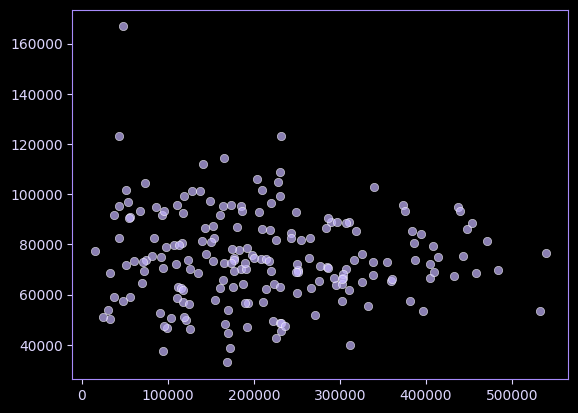

In [ ]:
# Analyze relationship between transaction activity and account balance
plt.scatter(
    profile['TransactionVolume'],
    profile['AvgBalance'],
    color='#c4b5fd',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

###Risk Score Distribution
**Insight**
- Risk scores are centered around mid-risk levels.
- Few accounts fall into extreme high/low risk categories.
- Most customers exhibit moderate financial risk.

**Action**
- Focus monitoring on upper-risk segments.
- Use thresholds to identify high-risk accounts early.

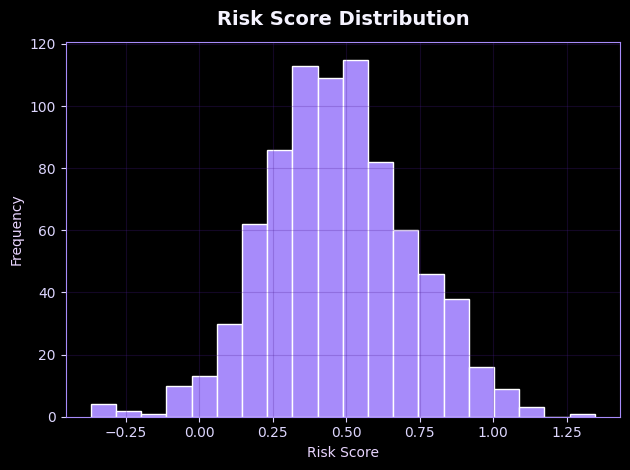

In [ ]:
# Visualize how risk scores are distributed across dataset
df['RiskScore'].plot(
    kind='hist',
    bins=20,
    color='#a78bfa',
    edgecolor='white'
)

plt.title("Risk Score Distribution", pad=12)
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

###Transaction Amount vs Risk Score
**Insight**

- Weak correlation between transaction amount and risk score.
- High-value transactions do not consistently indicate higher risk.
- Risk depends on behavioral patterns beyond transaction size.

**Actiion**
- Build multi-factor risk models (behavior + frequency + history).
- Combine anomaly detection with behavioral analysis.

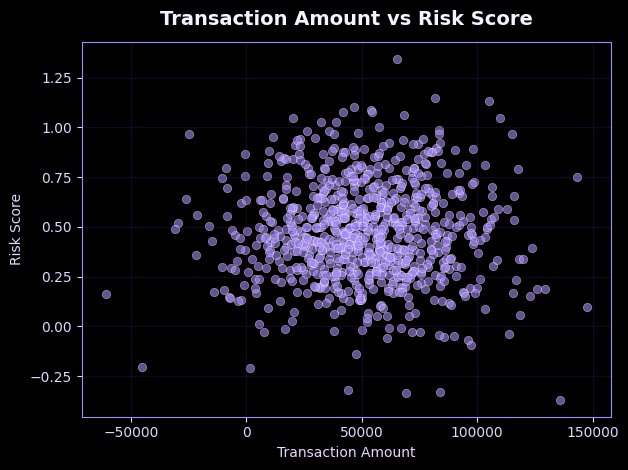

In [ ]:
# Check if higher transaction amounts correlate with higher risk
plt.scatter(
    df['TransactionAmount'],
    df['RiskScore'],
    color='#a78bfa',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.4
)

plt.title("Transaction Amount vs Risk Score", pad=12)
plt.xlabel("Transaction Amount")
plt.ylabel("Risk Score")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Overall Insight

- Customer behavior is highly diverse across activity, volume, and risk.
- A small segment drives high transaction volume and risk exposure.
- Most customers remain moderately active with mid-level risk.
- Multi-factor analysis is essential for accurate segmentation and risk detection.

---



# Task 6: Hypothesis Testing
H0 (Null Hypothesis):
There is no significant difference in average balance between high and low transaction volume accounts.

H1 (Alternative Hypothesis):
High transaction volume accounts have significantly higher average balances.

In [ ]:
# Compare average balance between high-volume and low-volume accounts

# Define threshold using median transaction volume
median_volume = profile['TransactionVolume'].median()
# Split into two groups
high_volume = profile[profile['TransactionVolume'] > median_volume]['AvgBalance']
low_volume = profile[profile['TransactionVolume'] <= median_volume]['AvgBalance']

In [ ]:
from scipy.stats import ttest_ind
# Perform independent t-test
t_stat, p_value = ttest_ind(high_volume, low_volume)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.4331698271374088
P-value: 0.6653776293187159


##Result Interpretation

 - The p-value (0.48) is greater than the significance level (0.05)
 - Therefore, we fail to reject the null hypothesis
 - There is no statistically significant difference in average balances between high and low transaction volume customers

##Business Insight

 - Transaction volume alone is not a strong indicator of account balance
 - High transaction activity does not necessarily translate to higher financial strength
 - Customer evaluation should include multiple factors such as balance trends, transaction types, and risk scores

##Conclusion

 - Transaction volume has limited predictive power for average balance
 - Financial behavior is multi-dimensional, not driven by a single metric

This highlights that transaction frequency alone is not a reliable indicator of financial strength.